## Seminar and homework (10 points total)

Today we shall compose encoder-decoder neural networks and apply them to the task of machine translation.

![img](https://esciencegroup.files.wordpress.com/2016/03/seq2seq.jpg)
_(img: esciencegroup.files.wordpress.com)_


Encoder-decoder architectures are about converting anything to anything, including
 * Machine translation and spoken dialogue systems
 * [Image captioning](http://mscoco.org/dataset/#captions-challenge2015) and [image2latex](https://openai.com/requests-for-research/#im2latex) (convolutional encoder, recurrent decoder)
 * Generating [images by captions](https://arxiv.org/abs/1511.02793) (recurrent encoder, convolutional decoder)
 * Grapheme2phoneme - convert words to transcripts

## Our task: macNine translation

We gonna try our encoder-decoder models on russian to englisN macNine translation problem. More specifically, we'll translate hotel and hostel descriptions. This task shows the scale of machine translation while not requiring you to train your model for weeks if you don't use GPU.

Before we get to the architecture, there's some preprocessing to be done. ~~Go tokenize~~ Alright, this time we've done preprocessing for you. As usual, the data will be tokenized with WordPunctTokenizer.

However, there's one more thing to do. Our data lines contain unique rare words. If we operate on a word level, we will have to deal with large vocabulary size. If instead we use character-level models, it would take lots of iterations to process a sequence. This time we're gonna pick something inbetween.

One popular approach is called [Byte Pair Encoding](https://github.com/rsennrich/subword-nmt) aka __BPE__. The algorithm starts with a character-level tokenization and then iteratively merges most frequent pairs for N iterations. This results in frequent words being merged into a single token and rare words split into syllables or even characters.



In [1]:
import os
from IPython.display import clear_output

notebook_dir = "/home/balabaevvl/courses/nlp/nlp_course/week03_attention"  # notebook's dir
os.chdir(notebook_dir)

print("Current dir:", os.getcwd())


Current dir: /home/balabaevvl/courses/nlp/nlp_course/week03_attention


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-fe2d8dfd-06f2-a5c4-a7fd-4a5f23947005"

import torch
device = torch.device('cuda:0')

In [3]:
!pip3 install torch>=1.3.0
!pip3 install subword-nmt &> log
!wget https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1 -O data.txt
!wget https://raw.githubusercontent.com/yandexdataschool/nlp_course/2020/week04_seq2seq/vocab.py -O vocab.py
# thanks to tilda and deephack teams for the data, Dmitry Emelyanenko for the code :)

clear_output()

In [4]:
from nltk.tokenize import WordPunctTokenizer
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE

tokenizer = WordPunctTokenizer()

def tokenize(x: str):
    return ' '.join(tokenizer.tokenize(x.lower()))

# split and tokenize the data
with open('train.en', 'w') as f_src,  open('train.ru', 'w') as f_dst:
    for line in open('data.txt'):
        src_line, dst_line = line.strip().split('\t')
        f_src.write(tokenize(src_line) + '\n')
        f_dst.write(tokenize(dst_line) + '\n')


# build and apply bpe vocs
bpe = {}
for lang in ['en', 'ru']:
    learn_bpe(open('./train.' + lang), open('bpe_rules.' + lang, 'w'), num_symbols=8000)
    bpe[lang] = BPE(open('./bpe_rules.' + lang))

    with open('train.bpe.' + lang, 'w') as f_out:
        for line in open('train.' + lang):
            f_out.write(bpe[lang].process_line(line.strip()) + '\n')


clear_output()


### Building vocabularies

We now need to build vocabularies that map strings to token ids and vice versa. We're gonna need these fellas when we feed training data into model or convert output matrices into words.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
from sklearn.model_selection import train_test_split

with open('./train.bpe.ru') as fru, open('./train.bpe.en') as fen:
    data_inp = np.array(fru.read().split('\n'))
    data_out = np.array(fen.read().split('\n'))

train_inp, dev_inp, train_out, dev_out = train_test_split(data_inp, 
                                                          data_out, 
                                                          test_size=3000,
                                                          random_state=42)
for i in range(3):
    print('inp:', train_inp[i])
    print('out:', train_out[i], end='\n\n')

# `...@@` means that `...` is not the end of the word and we continue word with next token
# `mi@@ gu@@ el` -> `miguel`

inp: на территории обустроена бесплатная частная парковка .
out: free private parking is available on site .

inp: кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .
out: guests can find many bars and restaurants within a 5 - minute walk .

inp: отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .
out: hotel san miguel is located in central more@@ lia , 750 metres from the city ’ s main square and cathedral .



In [7]:
from vocab import Vocab
input_voc = Vocab.from_lines(train_inp)
output_voc = Vocab.from_lines(train_out)

In [8]:
# Here's how you cast lines into ids and backwards.
batch_lines = sorted(train_inp, key=len)[5:10]
batch_ids = input_voc.to_matrix(batch_lines)
batch_lines_restored = input_voc.to_lines(batch_ids)

print("lines")
print(batch_lines)
print("\nwords to ids (0 = bos, 1 = eos):")
print(batch_ids)
print("\nback to words")
print(batch_lines_restored)

lines
[np.str_('гостевой дом r .'), np.str_('до афин — 20 км .'), np.str_('работает боулинг .'), np.str_('оборудован балкон .'), np.str_('подключен wi - fi .')]

words to ids (0 = bos, 1 = eos):
tensor([[   0, 2688, 2943, 1108,   29,    1,    1,    1],
        [   0, 2922, 1834, 8035,   59, 3800,   29,    1],
        [   0, 6030, 2083,   29,    1,    1,    1,    1],
        [   0, 4927, 1870,   29,    1,    1,    1,    1],
        [   0, 5549, 1453,   27,  592,   29,    1,    1]])

back to words
['гостевой дом r .', 'до афин — 20 км .', 'работает боулинг .', 'оборудован балкон .', 'подключен wi - fi .']


Draw source and translation length distributions to estimate the scope of the task.

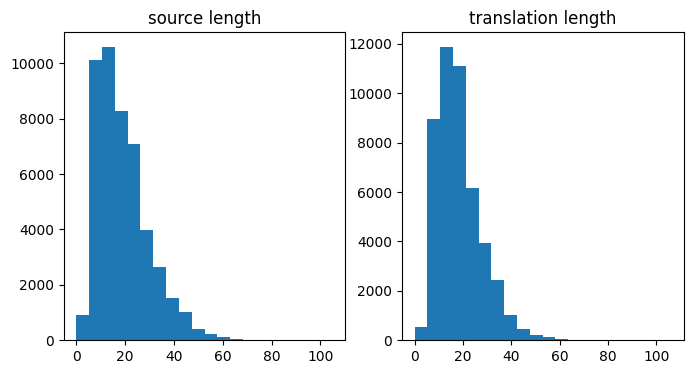

In [9]:
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(map(len, map(str.split, train_inp))), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(map(len, map(str.split, train_out))), bins=20);

### Encoder-decoder model

The code below contains a template for a simple encoder-decoder model: single GRU encoder/decoder, no attention or anything. This model is implemented for you as a reference and a baseline for your homework assignment.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [11]:
class BasicModel(nn.Module):
    def __init__(self, input_voc, output_voc, emb_size=64, hid_size=128):
        """
        A simple encoder-decoder seq2seq model
        """
        super().__init__() # initialize base class to track sub-layers, parameters, etc.

        self.input_voc = input_voc
        self.output_voc = output_voc
        self.hid_size = hid_size

        self.emb_input = nn.Embedding(len(input_voc), emb_size)
        self.emb_output = nn.Embedding(len(output_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)
        self.dec_start = nn.Linear(hid_size, hid_size)  # projection of last GRU cell of encoder to match decoder's starting dec_h

        self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(output_voc))


    def encode(self, inp, **flags):
        """
        Takes symbolic input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :returns: initial decoder state tensors, one or many
        """
        inp_emb = self.emb_input(inp)

        enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)
        # enc_seq: [batch, time, hid_size], last_state: [batch, hid_size]

        # NOTE: last_state is not _actually_ last because of padding, let's find the real last_state
        lengths = (inp != self.input_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]

        dec_start = self.dec_start(last_state)
        return [dec_start]

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors, same as returned by encode(...)
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, len(output_voc)]
        """
        dec_h = prev_state[0]

        emb = self.emb_output(prev_tokens)
        new_dec_state = self.dec0(emb, dec_h)
        output_logits = self.logits(new_dec_state)

        return [new_dec_state], output_logits

    def decode(self, initial_state, out_tokens, **flags):
        """ Iterate over reference tokens (out_tokens) with decode_step """
        batch_size = out_tokens.shape[0]
        state = initial_state

        # NOTE: initial logits - always predict BOS
        onehot_bos = F.one_hot(torch.full([batch_size], self.output_voc.bos_ix, dtype=torch.int64),
                               num_classes=len(self.output_voc)).to(device=out_tokens.device)
        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)

        logits_sequence = [first_logits]
        for i in range(out_tokens.shape[1] - 1):
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)

        return torch.stack(logits_sequence, dim=1)

    def forward(self, inp, out):
        """ Apply model in training mode """
        inp = torch.as_tensor(inp, dtype=torch.int64, device=next(self.parameters()).device)
        out = torch.as_tensor(out, dtype=torch.int64, device=next(self.parameters()).device)

        initial_state = self.encode(inp)
        return self.decode(initial_state, out)

    def decode_inference(self, initial_state, max_len=100, **flags):
        """ Generate translations from model (greedy version) """
        batch_size, device = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.output_voc.bos_ix, dtype=torch.int64, device=device)]
        all_states = [initial_state]

        for _ in range(max_len):
            state, logits = self.decode_step(state, outputs[-1])
            outputs.append(logits.argmax(dim=-1))
            all_states.append(state)

        return torch.stack(outputs, dim=1), all_states

    def translate_lines(self, input_lines, **kwargs):
        inp = self.input_voc.to_matrix(input_lines).to(device)

        initial_state = self.encode(inp)
        out_ids, states = self.decode_inference(initial_state, **kwargs)

        output_lines = self.output_voc.to_lines(out_ids.cpu().numpy())

        return output_lines, states


In [12]:
# debugging area
model = BasicModel(input_voc, output_voc).to(device)

dummy_inp_tokens = input_voc.to_matrix(sorted(train_inp, key=len)[5:10]).to(device)
dummy_out_tokens = output_voc.to_matrix(sorted(train_out, key=len)[5:10]).to(device)

h0 = model.encode(dummy_inp_tokens)
h1, logits1 = model.decode_step(h0, torch.arange(len(dummy_inp_tokens), device=device))

assert isinstance(h1, list) and len(h1) == len(h0)
assert h1[0].shape == h0[0].shape and not torch.allclose(h1[0], h0[0])
assert logits1.shape == (len(dummy_inp_tokens), len(output_voc))

logits_seq = model.decode(h0, dummy_out_tokens)
assert logits_seq.shape == (dummy_out_tokens.shape[0], dummy_out_tokens.shape[1], len(output_voc))

# full forward
logits_seq2 = model(dummy_inp_tokens, dummy_out_tokens)
assert logits_seq2.shape == logits_seq.shape

In [13]:
print("Source:")
print('\n'.join([line for line in train_inp[:3]]))
dummy_translations, dummy_states = model.translate_lines(train_inp[:3], max_len=25)

print("\nTranslations without training:")
print('\n'.join([line for line in dummy_translations]))

Source:
на территории обустроена бесплатная частная парковка .
кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .
отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .

Translations without training:
plant@@ sent@@ agia ci@@ ahmet dit@@ ill@@ markets acre robes sy hairdryers fishing ń ave enjoy ajara ău tains prepares wick tow@@ bair@@ plant@@ gab@@
plant@@ sent@@ agia ci@@ ahmet dit@@ ill@@ markets acre robes sy hairdryers fishing ń ave enjoy ajara ău tains prepares wick tow@@ bair@@ plant@@ gab@@
dre@@ thi@@ dered rodeway rodeway shi@@ ivano ge nier yogurt ciampino ciampino main@@ ride mac@@ are hue pe@@ las@@ qi@@ ares krabi os@@ os@@ gastrono@@


### Training loss (2 points)

Our training objective is almost the same as it was for neural language models:
$$ L = {\frac1{|D|}} \sum_{X, Y \in D} \sum_{y_t \in Y} - \log p(y_t \mid y_1, \dots, y_{t-1}, X, \theta) $$

where $|D|$ is the __total length of all sequences__, including BOS and first EOS, but excluding PAD.

In [14]:
def compute_loss(model, inp, out, **flags):
    """
    Compute loss (float32 scalar) as in the formula above
    :param inp: input tokens matrix, int32[batch, time]
    :param out: reference tokens matrix, int32[batch, time]
    
    In order to pass the tests, your function should
    * include loss at first EOS but not the subsequent ones
    * divide sum of losses by a sum of input lengths (use voc.compute_mask)
    """
    device = next(model.parameters()).device
    inp = torch.as_tensor(inp, dtype=torch.int64, device=device)

    mask = model.output_voc.compute_mask(out) # [batch_size, out_len]
    targets_1hot = F.one_hot(out, len(model.output_voc)).to(torch.float32)

    # outputs of the model, [batch_size, out_len, num_tokens]
    logits_seq = model.forward(inp, out)

    # log-probabilities of all tokens at all steps, [batch_size, out_len, num_tokens]
    logprobs_seq = torch.log(torch.softmax(logits_seq, dim=-1))
   
    # log-probabilities of correct outputs, [batch_size, out_len]
    logp_out = (logprobs_seq * targets_1hot).sum(dim=-1)
    # ^-- this will select the probability of the actual next token.
    # NOTE: you can compute loss more efficiently using using F.cross_entropy

    masked_logp_out = logp_out * mask
    total_len = mask.sum()
    loss = -masked_logp_out.sum() / total_len

    return loss

In [15]:
dummy_loss = compute_loss(model, dummy_inp_tokens, dummy_out_tokens)
print("Loss:", dummy_loss)
assert np.allclose(dummy_loss.item(), 7.5, rtol=0.1, atol=0.1), "We're sorry for your loss"

# test autograd
dummy_loss.backward()
for name, param in model.named_parameters():
    assert param.grad is not None and abs(param.grad.max()) != 0, f"Param {name} received no gradients"

Loss: 

tensor(7.4780, device='cuda:0', grad_fn=<DivBackward0>)


### Evaluation: BLEU

Machine translation is commonly evaluated with [BLEU](https://en.wikipedia.org/wiki/BLEU) score. This metric simply computes which fraction of predicted n-grams is actually present in the reference translation. It does so for n=1,2,3 and 4 and computes the geometric average with penalty if translation is shorter than reference.

While BLEU [has many drawbacks](http://www.cs.jhu.edu/~ccb/publications/re-evaluating-the-role-of-bleu-in-mt-research.pdf), it still remains the most commonly used metric and one of the simplest to compute.

In [16]:
from nltk.translate.bleu_score import corpus_bleu

@torch.no_grad()
def compute_bleu(model, inp_lines, out_lines, bpe_sep='@@ ', **flags):
    """
    Estimates corpora-level BLEU score of model's translations given inp and reference out
    Note: if you're serious about reporting your results, use https://pypi.org/project/sacrebleu
    """
    was_training = model.training
    model.eval()
    
    translations, _ = model.translate_lines(inp_lines, **flags)
    translations = [line.replace(bpe_sep, '') for line in translations]
    actual = [line.replace(bpe_sep, '') for line in out_lines]

    bleu = corpus_bleu(
        [[ref.split()] for ref in actual],
        [trans.split() for trans in translations],
        smoothing_function=lambda precisions, **kw: [p + 1.0 / p.denominator for p in precisions]
        ) * 100

    if was_training:
        model.train()

    return bleu

In [17]:
compute_bleu(model, dev_inp, dev_out)

0.002764457930795855

### Training loop

Training encoder-decoder models isn't that different from any other models: sample batches, compute loss, backprop and update

In [18]:
from IPython.display import clear_output
from tqdm import tqdm, trange


def train_model(metrics: dict[str, list[float]], model: nn.Module, opt, batch_size: int = 128, n_batches: int = 15000):
    for _ in trange(n_batches):
        step = len(metrics['train_loss']) + 1
        batch_ix = np.random.randint(len(train_inp), size=batch_size)
        batch_inp = input_voc.to_matrix(train_inp[batch_ix]).to(device)
        batch_out = output_voc.to_matrix(train_out[batch_ix]).to(device)

        opt.zero_grad()
        loss_t = compute_loss(model, batch_inp, batch_out)
        loss_t.backward()
        opt.step()

        metrics['train_loss'].append((step, loss_t.item()))

        if step % 100 == 0:
            metrics['dev_bleu'].append((step, compute_bleu(model, dev_inp, dev_out)))

            clear_output(True)
            plt.figure(figsize=(12,4))
            for i, (name, history) in enumerate(sorted(metrics.items())):
                plt.subplot(1, len(metrics), i + 1)
                plt.title(name)
                plt.plot(*zip(*history))
                plt.grid()
            plt.show()
            print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

    return metrics, model, opt

In [19]:
metrics = {'train_loss': [], 'dev_bleu': [] }

model = BasicModel(input_voc, output_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

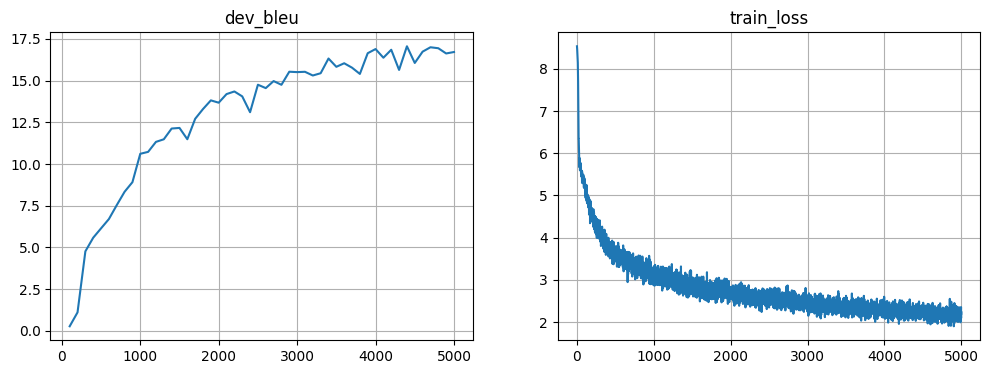

Mean loss=2.229


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [11:52<00:00,  7.02it/s]


In [20]:
metrics, model, opt = train_model(metrics, model, opt, batch_size=128, n_batches=5000)
# Note: it's okay if bleu oscillates up and down as long as it gets better on average over long term (e.g. 5k batches)

In [21]:
assert np.mean(metrics['dev_bleu'][-10:], axis=0)[1] > 15, "We kind of need a higher BLEU from you. Kind of right now."

In [22]:
for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в распоряжении гостей общая кухня и общая гостиная .
there is a shared kitchen and a shared kitchen at the property .

кроме того , предоставляется прокат велосипедов , услуги трансфера и бесплатная парковка .
the property offers free parking , and bicycles can be rented on site .

расстояние до города ки@@ сси@@ м@@ ми составляет 26 км .
the coastal town of the city is 6 km away .

апартаменты в пент@@ хаусе с общим открытым бассейном , садом , кондиционером и террасой для загара расположены в 5 минутах ходьбы от пляжа на курорте ка@@ бо - рой .
located in the centre of copacabana , this apartment features a terrace and a terrace with a terrace and a terrace .

апартаменты mo@@ s@@ co@@ w point - loft red square находятся в москве , в 200 метрах от большого театра .
apartment in santa maria is located in gdańsk . the apartment is a 1 - minute walk from the property .

в вашем распоряжении собственная ванная комната с душем и полотенцами .
private bathrooms also come with a bath and sh

### Your Attention Required

In this section we want you to improve over the basic model by implementing a simple attention mechanism.

This is gonna be a two-parter: building the __attention layer__ and using it for an __attentive seq2seq model__.

### Scaled Dot Product (3 Points)
Here you will have to implement a layer that computes a **scaled dot-product attention**:

Given encoder sequence $h^e_0, h^e_1, h^e_2, \dots, h^e_T$ and a single decoder state $h^d$,

* Project the decoder state into a **query** vector
  $$q = W_q h^d$$
* Project encoder states into **keys** and **values**
  $$k_t = W_k h^e_t, \quad v_t = W_v h^e_t$$
* Compute logits as **scaled dot products** between the query and each key
  $$a_t = \frac{q \cdot k_t}{\sqrt{d_k}}$$
  where $d\_k$ is the key/query dimensionality.
* Convert logits into probabilities using softmax
  $$p_t = \frac{e^{a_t}}{\sum_\tau e^{a_\tau}}$$
* Add up encoder values with probabilities to get the **attention response**
  $$attn = \sum_t p_t \cdot v_t$$

In [23]:
import math

In [24]:
class DotProductAttentionLayer(nn.Module):
    def __init__(self, enc_size, dec_size, hid_size):
        """
        Scaled dot-product attention with projections
        :param enc_size: num units in encoder state
        :param dec_size: num units in decoder state
        :param hid_size: dimension of query/key space (d_k)
        """
        super().__init__()

        self.enc_size = enc_size
        self.dec_size = dec_size
        self.hid_size = hid_size

        # Define projection layers
        # W_q, W_k, W_v project decoder states into query, key, value
        self.wq = nn.Linear(dec_size, hid_size, bias=False)
        self.wk = nn.Linear(enc_size, hid_size, bias=False)
        self.wv = nn.Linear(enc_size, hid_size, bias=False)

    def forward(self, enc, dec, input_mask):
        """
        # B - batch_size
        # T - ninp
        # H - hid_size

        Compute attention response and weights
        :param enc: encoder sequence [B, T, enc_size]
        :param dec: decoder state [B, dec_size]
        :param input_mask: mask [B, T] (0 = padding)
        :returns: attn [B, H], probs [B, T]
        """

        q = self.wq(dec).unsqueeze(1)                           # [B, 1, H]; unsqueeze, so we could multiply with k.T
        k = self.wk(enc)                                        # [B, T, H]
        v = self.wv(enc)                                        # [B, T, H]

        logits = torch.bmm(q, k.transpose(1, 2)).squeeze(1)     # [B, T]
        scaled_logits = logits / math.sqrt(self.hid_size)
        masked_logits = scaled_logits.masked_fill(~input_mask, float('-inf'))

        probs = torch.softmax(masked_logits, dim=-1)            # [B, T]

        attention = torch.bmm(probs.unsqueeze(1), v).squeeze(1) # [B, H]

        return attention, probs


### Seq2seq model with attention (3 points)

You can now use the attention layer to build a network. The simplest way to implement attention is to use it in decoder phase:
![img](https://i.imgur.com/6fKHlHb.png)

_image from distill.pub [article](https://distill.pub/2016/augmented-rnns/)_

On every step, use __previous__ decoder state to obtain attention response. Then feed concat this response to the inputs of next attention layer.

The key implementation detail here is __model state__. Put simply, you can add any tensor into the list of `encode` outputs. You will then have access to them at each `decode` step. This may include:
* Last RNN hidden states (as in basic model)
* The whole sequence of encoder outputs (to attend to) and mask
* Attention probabilities (to visualize)

_There are, of course, alternative ways to wire attention into your network and different kinds of attention. Take a look at [this](https://arxiv.org/abs/1609.08144), [this](https://arxiv.org/abs/1706.03762) and [this](https://arxiv.org/abs/1808.03867) for ideas. And for image captioning/im2latex there's [visual attention](https://arxiv.org/abs/1502.03044)_

In [25]:
class AttentiveModel(BasicModel):
    def __init__(self, input_voc, output_voc,
                 emb_size=64, hid_size=128, attn_size=128):
        """ Translation model that uses attention. See instructions above. """
        super().__init__(input_voc, output_voc, emb_size=emb_size, hid_size=hid_size)
        self.attention = DotProductAttentionLayer(hid_size, hid_size, attn_size)

        self.dec0 = nn.GRUCell(emb_size  + attn_size, hid_size)

    def encode(self, inp, **flags):
        """
        Takes symbolic input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :return: a list of initial decoder state tensors
        """
        inp_emb = self.emb_input(inp)

        enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)   # [B, T, H], [B, H]

        lengths = (inp != self.input_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]   # [B, H]

        dec_start = self.dec_start(last_state)
        mask = (torch.arange(inp.size(1), device=inp.device).unsqueeze(0) <= lengths.unsqueeze(1)).bool()

        return [enc_seq, dec_start, mask]

   
    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, n_tokens]
        """
        emb = self.emb_output(prev_tokens)
        
        enc_seq, dec_h, mask = prev_state
        attention, probs = self.attention(enc_seq, dec_h, mask)
        dec_inp = torch.cat([emb, attention], dim=-1)            # [B, E+A]

        new_dec_h = self.dec0(dec_inp, dec_h)                    # [B, H]
        output_logits = self.logits(new_dec_h)

        state = [enc_seq, new_dec_h, mask]
        return state, output_logits


### Training attentive model

Please reuse the infrastructure you've built for the regular model. I hope you didn't hard-code anything :)

In [26]:
metrics = {'train_loss': [], 'dev_bleu': [] }

model = AttentiveModel(input_voc, output_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

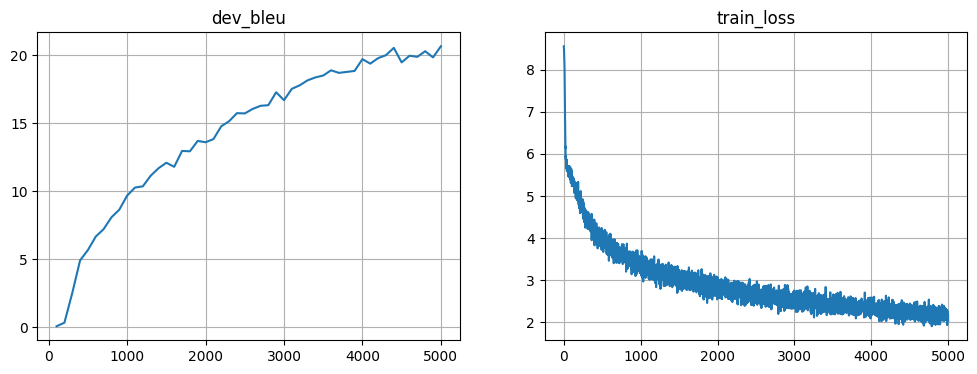

Mean loss=2.118


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [18:24<00:00,  4.53it/s]


In [27]:
metrics, model, opt = train_model(metrics, model, opt, batch_size=128, n_batches=5000)

In [28]:
print(f"Final BLEU: {np.mean(metrics['dev_bleu'][-10:], axis=0)[1]}\n")

for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

Final BLEU: 19.97310869193158

в распоряжении гостей общая кухня и общая гостиная .
there is a shared kitchen and a shared lounge .

кроме того , предоставляется прокат велосипедов , услуги трансфера и бесплатная парковка .
the property offers free parking , and shuttle service is available .

расстояние до города ки@@ сси@@ м@@ ми составляет 26 км .
the town of is 26 km from the property .

апартаменты в пент@@ хаусе с общим открытым бассейном , садом , кондиционером и террасой для загара расположены в 5 минутах ходьбы от пляжа на курорте ка@@ бо - рой .
located in the village of amal@@ kap@@ ano , a 5 - minute walk from the beach , apartment offers a sun terrace and a terrace .

апартаменты mo@@ s@@ co@@ w point - loft red square находятся в москве , в 200 метрах от большого театра .
located in the centre of ś@@ win@@ ou@@ ści@@ ści@@ ska , 200 metres from the city centre .

в вашем распоряжении собственная ванная комната с душем и полотенцами .
featuring a shower , private bathrooms

### Visualizing model attention (2 points)

After training the attentive translation model, you can check it's sanity by visualizing its attention weights.

We provided you with a function that draws attention maps using [`Bokeh`](https://bokeh.pydata.org/en/latest/index.html). Once you managed to produce something better than random noise, please save at least 3 attention maps and __submit them to anytask__ alongside this notebook to get the max grade. Saving bokeh figures as __cell outputs is not enough!__ (TAs can't see saved bokeh figures in anytask). You can save bokeh images as screenshots or using this button:

![bokeh_panel](https://github.com/yandexdataschool/nlp_course/raw/2019/resources/bokeh_panel.png)

__Note:__ you're not locked into using bokeh. If you prefer a different visualization method, feel free to use that instead of bokeh.

In [30]:
import bokeh.plotting as pl
import bokeh.models as bm
from bokeh.io import output_notebook, show
output_notebook()

def draw_attention(inp_line, translation, probs):
    """ An intentionally ambiguous function to visualize attention weights """
    inp_tokens = input_voc.tokenize(inp_line)
    trans_tokens = output_voc.tokenize(translation)
    probs = probs[:len(trans_tokens), :len(inp_tokens)]

    fig = pl.figure(x_range=(0, len(inp_tokens)), y_range=(0, len(trans_tokens)),
                    x_axis_type=None, y_axis_type=None, tools=[])
    fig.image([probs[::-1]], 0, 0, len(inp_tokens), len(trans_tokens))

    fig.add_layout(bm.LinearAxis(axis_label='source tokens'), 'above')
    fig.xaxis.ticker = np.arange(len(inp_tokens)) + 0.5
    fig.xaxis.major_label_overrides = dict(zip(np.arange(len(inp_tokens)) + 0.5, inp_tokens))
    fig.xaxis.major_label_orientation = 45

    fig.add_layout(bm.LinearAxis(axis_label='translation tokens'), 'left')
    fig.yaxis.ticker = np.arange(len(trans_tokens)) + 0.5
    fig.yaxis.major_label_overrides = dict(zip(np.arange(len(trans_tokens)) + 0.5, trans_tokens[::-1]))
    show(fig)

Loading BokehJS ...

In [31]:
print("Source:")
print('\n'.join([line for line in train_inp[:3]]))
trans, states = model.translate_lines(train_inp[:3])

print("\nTranslations without training:")
print('\n'.join([line for line in trans]))

Source:
на территории обустроена бесплатная частная парковка .
кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .
отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .

Translations without training:
free private parking is available on site .
alternatively , bars and restaurants are within a 5 - minute walk .
the hotel is located in the centre of saint petersburg , 400 metres from the main square and the cathedral .


In [32]:
x_input = dev_inp[::500]

trans, states = model.translate_lines(x_input)

# select attention probs from model state (you may need to change this for your custom model)
# attention_probs below must have shape [batch_size, translation_length, input_length], extracted from states
# e.g. if attention probs are at the end of each state, use np.stack([state[-1] for state in states], axis=1)
probs = []
for state in states:
    attention, prob = model.attention(*state)
    probs.append(prob.cpu().detach().numpy())

attention_probs = np.stack(np.array(probs), axis=1)

In [33]:
for i in range(5):
    draw_attention(x_input[i], trans[i], attention_probs[:, i])
# Does it look fine already? don't forget to save images for anytask!

__Note 1:__ If the attention maps are not iterpretable, try starting encoder from zeros (instead of dec_start), forcing model to use attention.

__Note 2:__ If you're studying this course as a YSDA student, please submit __attention screenshots__ alongside your notebook.

# Goind deeper (2++ points each)

We want you to find the best model for the task. Use everything you know.

* different recurrent units: rnn/gru/lstm; deeper architectures
* bidirectional encoder, different attention methods for decoder (additive, dot-product, multi-head)
* word dropout, training schedules, anything you can imagine
* replace greedy inference with beam search

For a better grasp of seq2seq We recommend you to conduct at least one experiment from one of the bullet-points or your alternative ideas. As usual, describe what you tried and what results you obtained in a short report.

## 1. Starting from (3/4): 
###  - LSTM + Deeper
###  - Gradient Scaling + L2 Regularization  + Patience-based Early Stopping
###  - Beam Search

In [34]:
class DeepSeq2SeqModel(nn.Module):
    """
    ✅ LSTM + Deeper
    ✅ Gradient Scaling + L2 Regularization + Patience-based Early Stopping
    ✅ Beam Search

    ---

    ***I wrote `okay` emoji myself, no GPT***
    """

    def __init__(self, 
                 input_voc: list[str], output_voc: list[str], 
                 emb_size:int = 128, hidden_size: int = 128, attention_size: int = 128,
                 lstm_layers: int = 1, lstm_dropout: float = 0.1):
        super().__init__()

        self.input_voc = input_voc
        self.output_voc = output_voc
        self.hidden_size = hidden_size

        self.emb_input = nn.Embedding(len(input_voc), emb_size)
        self.emb_output = nn.Embedding(len(output_voc), emb_size)

        self.enc0 = nn.LSTM(
            input_size=emb_size,
            hidden_size=hidden_size,
            num_layers=lstm_layers,
            dropout=(lstm_dropout if lstm_layers > 1 else 0.0),
            batch_first=True
        )
        self.enc_to_dec_proj = nn.Linear(hidden_size, hidden_size)

        self.attention = DotProductAttentionLayer(hidden_size, hidden_size, attention_size)
        self.dec0 = nn.LSTMCell(emb_size  + attention_size, hidden_size)

        self.logits = nn.Linear(hidden_size, len(output_voc))


    def encode(self, x_input):
        x_emb = self.emb_input(x_input)
        enc_seq, (h_n, c_n) = self.enc0(x_emb)                          # [B, T, H], [B, H]

        lengths = (x_input != self.input_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(x_input.shape[1] - 1)
        last_enc_state = enc_seq[torch.arange(len(enc_seq)), lengths]   # [B, H]

        dec_h0 = self.enc_to_dec_proj(last_enc_state)                   # [B, H]
        dec_c0 = torch.zeros_like(dec_h0)                               # [B, H]

        enc_mask = (torch.arange(x_input.size(1), device=x_input.device).unsqueeze(0) <= lengths.unsqueeze(1)).bool()

        return [enc_seq, (dec_h0, dec_c0), enc_mask]

    def decode_step(self, prev_state, prev_tokens):
        enc_seq, (dec_h, dec_c), mask = prev_state
        emb = self.emb_output(prev_tokens)                        # [B, E]

        context, _ = self.attention(enc_seq, dec_h, mask)      # [B, A]
        dec_inp = torch.cat([emb, context], dim=-1)            # [B, E + A]

        new_h, new_c = self.dec0(dec_inp, (dec_h, dec_c))      # [B, H], [B, H]
        logits = self.logits(new_h)                            # [B, V]

        new_state = [enc_seq, (new_h, new_c), mask]

        return new_state, logits

    def decode(self, initial_state, out_tokens):
        device = next(self.parameters()).device

        batch_size = out_tokens.shape[0]
        state = initial_state

        # NOTE: initial logits - always predict BOS
        onehot_bos = F.one_hot(
            torch.full([batch_size], self.output_voc.bos_ix, dtype=torch.int64),
            num_classes=len(self.output_voc)
        ).to(device=device)

        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)

        logits_sequence = [first_logits]
        for i in range(out_tokens.shape[1] - 1):
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)

        return torch.stack(logits_sequence, dim=1)

    def forward(self, inp, out):
        initial_state = self.encode(inp)

        return self.decode(initial_state, out)

    def _decode_inference_greedy(self, outputs, states, max_len):
        for _ in range(max_len):
            state, logits = self.decode_step(states[-1], outputs[-1])

            chosen = logits.argmax(dim=-1)

            outputs.append(chosen)
            states.append(state)

        return outputs, states

    def _decode_inference_beam(self, outputs, states, max_len, beam_size=4, alpha=0.7):
        """
        Batched beam search.
        Selects best 1 per batch
        
        length penalty: lp(L) = ((5+L)^alpha) / (6^alpha)
        """
        device = next(self.parameters()).device

        enc_seq, (h0, c0), enc_mask = states[0]
        B = enc_seq.size(0)
        BOS, EOS = self.output_voc.bos_ix, self.output_voc.eos_ix

        lp = lambda L: ((5.0 + L) ** alpha) / (6.0 ** alpha)

        best_per_batch = []
        for b in range(B):
            # each item: (logprob, tokens(list[int]), (h,c))
            beam = [(0.0, [BOS], (h0[b:b+1], c0[b:b+1]))]
            finished = []

            for _ in range(max_len):
                new_beam = []

                for logp_sum, toks, (h, c) in beam:
                    prev = torch.tensor([toks[-1]], device=device)

                    state_b = [enc_seq[b:b+1], (h, c), enc_mask[b:b+1]]
                    state_b, logits = self.decode_step(state_b, prev)

                    nh, nc = state_b[1]

                    logp = F.log_softmax(logits, dim=-1)[0]
                    topk_lp, topk_ix = torch.topk(logp, beam_size)

                    for lp_i, ix in zip(topk_lp.tolist(), topk_ix.tolist()):
                        new_tokens = toks + [ix]
                        new_logp   = logp_sum + lp_i
                        if ix == EOS:
                            finished.append((new_logp / lp(len(new_tokens)), new_tokens))
                        else:
                            new_beam.append((new_logp, new_tokens, (nh, nc)))

                if not new_beam and finished:
                    break

                new_beam.sort(key=lambda x: x[0], reverse=True)
                beam = new_beam[:beam_size]

            if finished:
                best = max(finished, key=lambda x: x[0])[1]
            else:
                best = max(beam, key=lambda x: x[0] / lp(len(x[1])))[1]

            best_per_batch.append(torch.tensor(best, device=device, dtype=torch.long))

        # pad to [B, T*]
        maxL = max(len(t) for t in best_per_batch)
        out_mat = torch.full((B, maxL), EOS, dtype=torch.long, device=device)
        for b, seq in enumerate(best_per_batch):
            out_mat[b, :seq.numel()] = seq

        chosen_states = [states[0]]
        cur = states[0]
        for t in range(maxL - 1):  # first token = BOS
            cur, _ = self.decode_step(cur, out_mat[:, t])
            chosen_states.append(cur)

        outputs = [out_mat[:, t] for t in range(maxL)]
        return outputs, chosen_states

    def decode_inference(self, initial_state, max_len=100, regime: str = "greedy"):
        """
        :regime: "beam" / "greedy"
        """
        device = next(self.parameters()).device

        batch_size = len(initial_state[0])

        outputs = [torch.full([batch_size], self.output_voc.bos_ix, dtype=torch.int64, device=device)]
        states = [initial_state]

        if regime == "greedy":
            outputs, states = self._decode_inference_greedy(outputs, states, max_len)
        elif regime == "beam":
            outputs, states = self._decode_inference_beam(outputs, states, max_len)

        return torch.stack(outputs, dim=1), states

    def translate_lines(self, input_lines, regime: str = "greedy"):
        device = next(self.parameters()).device
        x_input = self.input_voc.to_matrix(input_lines).to(device)

        initial_state = self.encode(x_input)
        out_ids, states = self.decode_inference(initial_state, regime=regime)

        output_lines = self.output_voc.to_lines(out_ids.cpu().numpy())

        return output_lines, states


In [40]:
def enchanced_train_model(
    metrics: dict[str, list[tuple[int, float]]],
    model: nn.Module,
    opt: torch.optim.Optimizer,
    scaler=None,
    batch_size: int = 128,
    n_batches: int = 10000,
    eval_every: int = 100,
    save_every: int = 1000,
    save_dir: str = "checkpoints",
    early_stop: bool = True,
    patience: int = 10,
    min_delta: float = 0.0,
    clip_grad_norm: float = 1.0,
):
    os.makedirs(save_dir, exist_ok=True)

    device = next(model.parameters()).device
    model.train()

    class EarlyStopper:
        def __init__(self, patience=10, min_delta=0.0):
            self.patience = patience
            self.min_delta = min_delta
            self.best = -float("inf")
            self.best_step = None
            self.bad = 0
        def update(self, value, step):
            if value > self.best + self.min_delta:
                self.best = value
                self.best_step = step
                self.bad = 0
                return True
            else:
                self.bad += 1
                return False
        @property
        def should_stop(self):
            return self.bad >= self.patience

    stopper = EarlyStopper(patience, min_delta) if early_stop else None
    best_ckpt = os.path.join(save_dir, "best.pt")

    for _ in trange(n_batches):
        step = len(metrics.get('train_loss', [])) + 1

        # ---- sample batch ----
        batch_ix = np.random.randint(len(train_inp), size=batch_size)
        batch_inp = input_voc.to_matrix(train_inp[batch_ix]).to(device, non_blocking=True)
        batch_out = output_voc.to_matrix(train_out[batch_ix]).to(device, non_blocking=True)

        # ---- forward/backward ----
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            loss_t = compute_loss(model, batch_inp, batch_out)

        if scaler is None:
            loss_t.backward()
            if clip_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
            opt.step()
        else:
            scaler.scale(loss_t).backward()
            scaler.unscale_(opt)  # !! unscale before clipping
            if clip_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
            scaler.step(opt)
            scaler.update()

        # ---- log train loss ----
        metrics.setdefault('train_loss', []).append((step, float(loss_t.item())))

        # ---- save periodic checkpoint ----
        if save_every and step % save_every == 0:
            ckpt_path = os.path.join(save_dir, f"model_step_{step}.pt")
            torch.save({
                'step': step,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': opt.state_dict(),
                'scaler_state_dict': scaler.state_dict() if scaler else None,
                'metrics': metrics,
            }, ckpt_path)
            print(f"✅ Saved checkpoint at step {step}: {ckpt_path}")

        # ---- evaluation ----
        if eval_every and step % eval_every == 0:
            model.eval()
            dev_bleu = compute_bleu(model, dev_inp, dev_out)
            model.train()

            metrics.setdefault('dev_bleu', []).append((step, float(dev_bleu)))

            # early stopping on BLEU
            if early_stop:
                improved = stopper.update(dev_bleu, step)
                if improved:
                    torch.save({
                        'step': step,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': opt.state_dict(),
                        'scaler_state_dict': scaler.state_dict() if scaler else None,
                        'best_metric': dev_bleu,
                        'metrics': metrics,
                    }, best_ckpt)
                    print(f"🌟 New best BLEU {dev_bleu:.3f} at step {step} — saved {best_ckpt}")
                elif stopper.should_stop:
                    print(f"⏹ Early stopping at step {step} (best at {stopper.best_step}, BLEU={stopper.best:.3f})")
                    # clip metrics up to best step
                    for k in list(metrics.keys()):
                        metrics[k] = [(s, v) for (s, v) in metrics[k] if s <= stopper.best_step]
                    break

            clear_output(True)
            plt.figure(figsize=(12,4))
            for i, (name, history) in enumerate(sorted(metrics.items())):
                plt.subplot(1, len(metrics), i + 1)
                plt.title(name)
                if len(history) > 0:
                    xs, ys = zip(*history)
                    plt.plot(xs, ys)
                plt.grid()
            plt.show()
            if len(metrics['train_loss']) >= 10:
                print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

    # ---- restore best weights if early stop used ----
    if early_stop and os.path.exists(best_ckpt):
        ckpt = torch.load(best_ckpt, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])

        if scaler and ckpt.get('scaler_state_dict') is not None:
            scaler.load_state_dict(ckpt['scaler_state_dict'])
        print(f"✅ Restored best checkpoint from step {ckpt['step']} (BLEU={ckpt.get('best_metric', float('nan')):.3f})")

        # ensure metrics clipped to best step (in case didn't stop)
        if stopper and stopper.best_step is not None:
            for k in list(metrics.keys()):
                metrics[k] = [(s, v) for (s, v) in metrics[k] if s <= stopper.best_step]

    return metrics, model, opt, scaler


In [54]:
metrics = {'train_loss': [], 'dev_bleu': [] }

deep_model = DeepSeq2SeqModel(
    input_voc, output_voc, 
    lstm_layers=4,
    emb_size=128, hidden_size=128, attention_size=128,
)
device = torch.device('cuda')
# device = torch.device('cuda:2')
deep_model = deep_model.to(device)

opt = torch.optim.Adam(deep_model.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

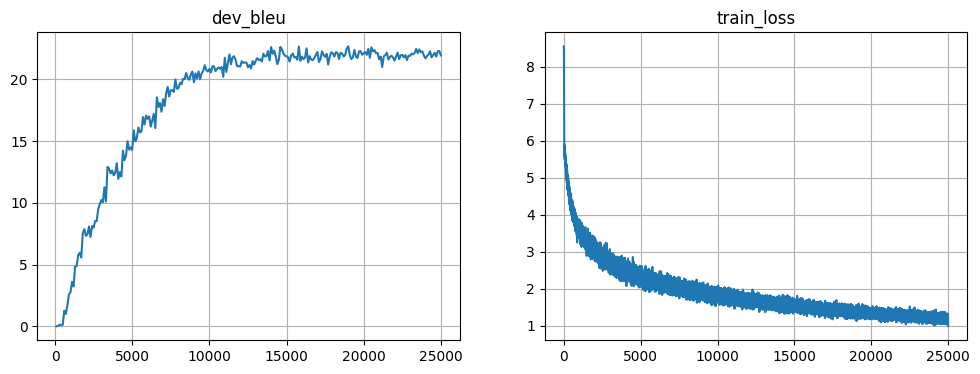

Mean loss=1.158


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [1:59:01<00:00,  3.50it/s]


In [ ]:
metrics, deep_model, opt, scaler = enchanced_train_model(
    metrics, deep_model, opt, scaler,
    save_dir="checkpoints_deep",
    n_batches=25000, clip_grad_norm=None, early_stop=True
)

In [56]:
print(f"Final BLEU: {np.mean(metrics['dev_bleu'][-10:], axis=0)[1]}\n")

for inp_line, trans_line in zip(dev_inp[::500], deep_model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

Final BLEU: 22.03785203820653

в распоряжении гостей общая кухня и общая гостиная .
there is a shared kitchen and a lounge area .

кроме того , предоставляется прокат велосипедов , услуги трансфера и бесплатная парковка .
free parking and a free parking are available .

расстояние до города ки@@ сси@@ м@@ ми составляет 26 км .
it is 26 km from the property .

апартаменты в пент@@ хаусе с общим открытым бассейном , садом , кондиционером и террасой для загара расположены в 5 минутах ходьбы от пляжа на курорте ка@@ бо - рой .
located 5 minutes ’ walk from the beach in the centre of ces@@ ky kru@@ m@@ bo , this apartment features a 2 - bedroom , garden and outdoor pool .

апартаменты mo@@ s@@ co@@ w point - loft red square находятся в москве , в 200 метрах от большого театра .
casa vacan@@ za apartments a rest@@ ric@@ elli apartment is set 200 metres from the property , while the apartment is 200 metres from fountain square .

в вашем распоряжении собственная ванная комната с душем и полот

## 2. Adding on top (4/4): Bidirectional + MultiHead

In [57]:
class MultiHeadDotProductAttention(nn.Module):
    def __init__(self, enc_size, dec_size, num_heads, head_dim, out_dim=None):
        super().__init__()

        self.enc_size = enc_size
        self.dec_size = dec_size

        self.num_heads = num_heads
        self.head_dim = head_dim
        self.out_dim = out_dim or (num_heads * head_dim)

        hh = num_heads * head_dim

        # **packed** projections 
        self.wq = nn.Linear(dec_size, hh, bias=False)
        self.wk = nn.Linear(enc_size, hh, bias=False)
        self.wv = nn.Linear(enc_size, hh, bias=False)

        self.wo = nn.Linear(hh, self.out_dim, bias=False)

    def forward(self, enc_seq, dec_h, input_mask):
        B, T, _ = enc_seq.shape

        Q = self.wq(dec_h)                                                 # [B, N * H]
        K = self.wk(enc_seq)                                               # [B, T, N * H]
        V = self.wv(enc_seq)                                               # [B, T, N * H]

        Q = Q.view(B, self.num_heads, self.head_dim)                        # [B, N, H]
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)     # [B, N, T, H]
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)     # [B, N, T, H]

        # [B, N, 1, H] x [B, N, H, T] -> [B, N, 1, T] -> [B, N, T]
        scores = torch.matmul(Q.unsqueeze(2), K.transpose(-1, -2)).squeeze(2)
        scores = scores / math.sqrt(self.head_dim)                          # [B, N, T]

        scores = scores.masked_fill(~input_mask.unsqueeze(1), float('-inf'))

        probs = torch.softmax(scores, dim=-1)                               # [B, N, T]

        # [B, H, 1, T] x [B, H, T, H] -> [B, N, 1, H] -> [B, N, H]
        heads = torch.matmul(probs.unsqueeze(2), V).squeeze(2)


        attention = heads.reshape(B, self.num_heads * self.head_dim)        # [B, N * H]
        out = self.wo(attention)                                           # [B, out_dim]

        return out, probs

In [58]:
class BigFatAssBidirectionalMultiHeadAttentionSeq2SeqModel(DeepSeq2SeqModel):
    """
    ✅ LSTM + Deeper
    ✅ Learning Rate Schedulling + Gradient Scaling + L2 Regularization
    ✅ Beam Search
    ✅ Bidirectional + MultiHead

    🍑 Big. Fat. Ass. Seq2Seq Model.
    It’s not fast, but it sure is thicc.
    
    ---

    ***I wrote `okay` emoji myself, no GPT***
    """

    def __init__(
        self, 
        input_voc: list[str], output_voc: list[str], 
        emb_size:int = 128, hidden_size: int = 128,
        lstm_layers: int = 1, lstm_dropout: float = 0.1,
        bidirectional_encoding: bool = True, 
        n_attention_heads: int = 2, attention_size: int = 128,
    ):
        super().__init__(input_voc, output_voc, emb_size, hidden_size, attention_size, lstm_layers, lstm_dropout)

        self.enc_dim = hidden_size * (2 if bidirectional_encoding else 1)

        self.enc0 = nn.LSTM(
            input_size=emb_size,
            hidden_size=hidden_size,
            num_layers=lstm_layers,
            dropout=(lstm_dropout if lstm_layers > 1 else 0.0),
            batch_first=True,
            bidirectional=bidirectional_encoding,
        )
        self.enc_to_dec_proj = nn.Linear(self.enc_dim, hidden_size)

        self.attention = MultiHeadDotProductAttention(self.enc_dim, hidden_size, n_attention_heads, attention_size)
        self.dec0 = nn.LSTMCell(emb_size + n_attention_heads * attention_size, hidden_size)

    def encode(self, x_input):
        x_emb = self.emb_input(x_input)
        enc_seq, (h_n, c_n) = self.enc0(x_emb)              # [B, T, enc_dim], [B, enc_dim]

        lengths = (x_input != self.input_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(x_input.shape[1] - 1)
        last_enc_state = enc_seq[torch.arange(len(enc_seq)), lengths]   # [B, enc_dim]

        dec_h0 = self.enc_to_dec_proj(last_enc_state)       # [B, H]
        dec_c0 = torch.zeros_like(dec_h0)                   # [B, H]

        enc_mask = (torch.arange(x_input.size(1), device=x_input.device).unsqueeze(0) <= lengths.unsqueeze(1)).bool()

        return [enc_seq, (dec_h0, dec_c0), enc_mask]

    def decode_step(self, prev_state, prev_tokens):
        enc_seq, (dec_h, dec_c), mask = prev_state
        emb = self.emb_output(prev_tokens)                        # [B, E]

        context, _ = self.attention(enc_seq, dec_h, mask)      # [B, A]
        dec_inp = torch.cat([emb, context], dim=-1)            # [B, E + A]

        new_h, new_c = self.dec0(dec_inp, (dec_h, dec_c))      # [B, H], [B, H]
        logits = self.logits(new_h)                            # [B, V]

        new_state = [enc_seq, (new_h, new_c), mask]

        return new_state, logits


In [ ]:
metrics = {'train_loss': [], 'dev_bleu': [] }

fatass_model = BigFatAssBidirectionalMultiHeadAttentionSeq2SeqModel(
    input_voc, output_voc, 
    emb_size=128, hidden_size=128,
    lstm_layers=3, lstm_dropout=0.1,
    bidirectional_encoding=True, 
    n_attention_heads=2, attention_size=128,
)
# it's really BigFatAss, because it _solely_ takes 14360MB/16375MB of NVIDIA RTX A4000
device = torch.device('cuda')
fatass_model = fatass_model.to(device)

opt = torch.optim.Adam(fatass_model.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

In [62]:
print(f"Number of trainable parameters: {sum(p.numel() for p in fatass_model.parameters() if p.requires_grad)}")

Number of trainable parameters: 4615161


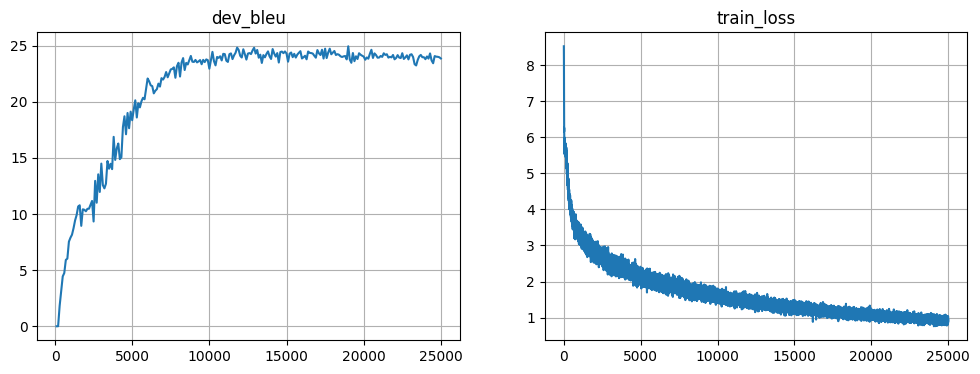

Mean loss=0.936


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [2:14:57<00:00,  3.09it/s]


In [60]:
metrics, fatass_model, opt, scaler = enchanced_train_model(
    metrics, fatass_model, opt, scaler,
    save_dir="checkpoints_fatass",
    n_batches=25000, clip_grad_norm=None, early_stop=True
)

In [61]:
print(f"Final BLEU: {np.mean(metrics['dev_bleu'][-10:], axis=0)[1]}\n")

for inp_line, trans_line in zip(dev_inp[::500], fatass_model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

Final BLEU: 23.911186212694837

в распоряжении гостей общая кухня и общая гостиная .
a shared kitchen and a shared lounge are available .

кроме того , предоставляется прокат велосипедов , услуги трансфера и бесплатная парковка .
car rental , dry cleaning services and free parking are available .

расстояние до города ки@@ сси@@ м@@ ми составляет 26 км .
bangla road is 26 km away .

апартаменты в пент@@ хаусе с общим открытым бассейном , садом , кондиционером и террасой для загара расположены в 5 минутах ходьбы от пляжа на курорте ка@@ бо - рой .
offering a garden with a garden , a garden and a sun terrace , casa vacanze is a 5 - minute walk from playa de la vista .

апартаменты mo@@ s@@ co@@ w point - loft red square находятся в москве , в 200 метрах от большого театра .
apartment ar@@ ri@@ ona la mark@@ sa i is a holiday park , apartment ko@@ bul@@ ina is located in moscow . the 1@@ 42 km from church of the savior on spilled blood .

в вашем распоряжении собственная ванная комната с 

### (Optional 2+ points) Alternative Attention layer

You may compare scaled dot product with alternative additive attention implementation. Compare corresponding models metrics during training. Which is better?
___

Here you will have to implement a layer that computes a simple additive attention:

Given encoder sequence $ h^e_0, h^e_1, h^e_2, ..., h^e_T$ and a single decoder state $h^d$,

* Compute logits with a 2-layer neural network
$$a_t = linear_{out}(tanh(linear_{e}(h^e_t) + linear_{d}(h_d)))$$
* Get probabilities from logits,
$$ p_t = {{e ^ {a_t}} \over { \sum_\tau e^{a_\tau} }} $$

* Add up encoder states with probabilities to get __attention response__
$$ attn = \sum_t p_t \cdot h^e_t $$

You can learn more about attention layers in the lecture slides or [from this post](https://distill.pub/2016/augmented-rnns/).

In [ ]:
class AttentionLayer(nn.Module):
    def __init__(self, name, enc_size, dec_size, hid_size, activ=torch.tanh):
        """ A layer that computes additive attention response and weights """
        super().__init__()
        self.name = name
        self.enc_size = enc_size # num units in encoder state
        self.dec_size = dec_size # num units in decoder state
        self.hid_size = hid_size # attention layer hidden units
        self.activ = activ       # attention layer hidden nonlinearity
        
        # create trainable paramteres like this:
        self.<PARAMETER_NAME> = nn.Parameter(<INITIAL_VALUES>, requires_grad=True)
        <...>  # you will need a couple of these
        

    def forward(self, enc, dec, input_mask):
        """
        Computes attention response and weights
        :param enc: encoder activation sequence, float32[batch_size, ninp, enc_size]
        :param dec: single decoder state used as "query", float32[batch_size, dec_size]
        :param input_mask: mask on enc activatons (0 after first eos), float32 [batch_size, ninp]
        :returns: attn[batch_size, enc_size], probs[batch_size, ninp]
            - attn - attention response vector (weighted sum of enc)
            - probs - attention weights after softmax
        """

        # Compute logits
        <...>

        # Apply mask - if mask is 0, logits should be -inf or -1e9
        # You may need torch.where
        <...>

        # Compute attention probabilities (softmax)
        probs = <...>

        # Compute attention response using enc and probs
        attn = <...>

        return attn, probs